# JOBSHEET 2 (Klasifikasi Gambar)

## Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

try dataset MNIST

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


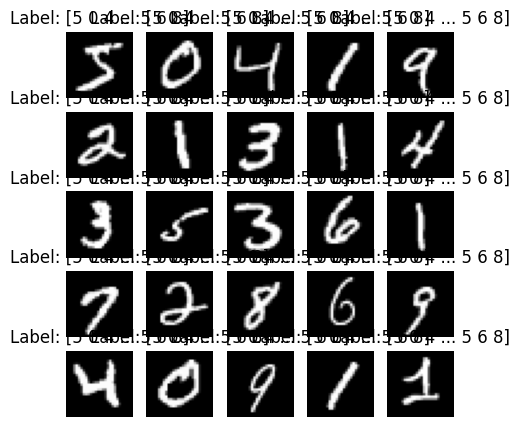

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train}")
  plt.axis('off')
plt.show()

## Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Traditional

using SVM algorithm

In [3]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# svm
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena svm berat
y_pred = clf.predict(x_test_flat)

print("Akurasi", accuracy_score(y_test, y_pred))

Akurasi 0.9101


## Praktikum D3 - Membangung CNN Sederhana

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9468 - loss: 0.1783 - val_accuracy: 0.9778 - val_loss: 0.0787
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 64s 32ms/step - accuracy: 0.9813 - loss: 0.0621 - val_accuracy: 0.9847 - val_loss: 0.0577
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.9872 - loss: 0.0411 - val_accuracy: 0.9858 - val_loss: 0.0532
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 69s 19ms/step - accuracy: 0.9907 - loss: 0.0290 - val_accuracy: 0.9865 - val_loss: 0.0525
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9928 - loss: 0.0213 - val_accuracy: 0.9853 - val_loss: 0.0602


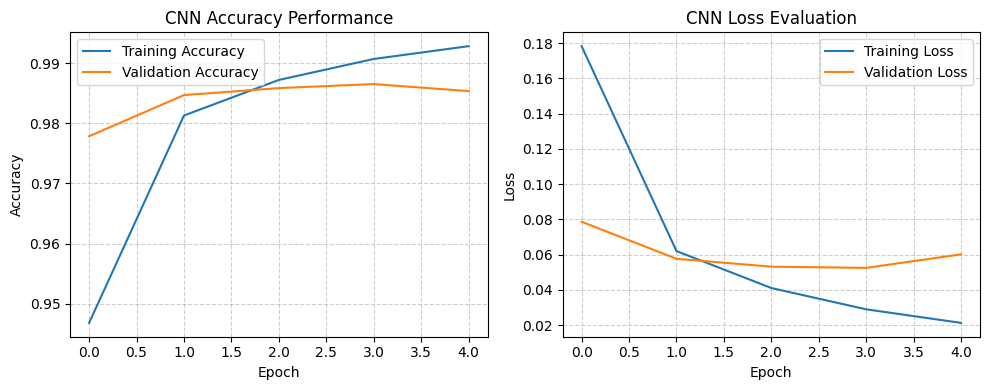

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Normalisasi Data (Asumsi x_train, y_train, x_test sudah di-load ke dalam memori)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Arsitektur Model Terstruktur
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Kompilasi Model dengan Error Handling yang Tepat
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Eksekusi Pelatihan
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

# 5. Visualisasi Metrik Performa
plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Tugas kecil: Tambahkan satu lapisan Conv2D lagi sebelum Flatten. Apakah akurasinya meningkat?

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.9523 - loss: 0.1582 - val_accuracy: 0.9797 - val_loss: 0.0680
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9848 - loss: 0.0492 - val_accuracy: 0.9887 - val_loss: 0.0404
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.9895 - loss: 0.0341 - val_accuracy: 0.9887 - val_loss: 0.0375
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9914 - loss: 0.0260 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 27ms/step - accuracy: 0.9940 - loss: 0.0188 - val_accuracy: 0.9905 - val_loss: 0.0385


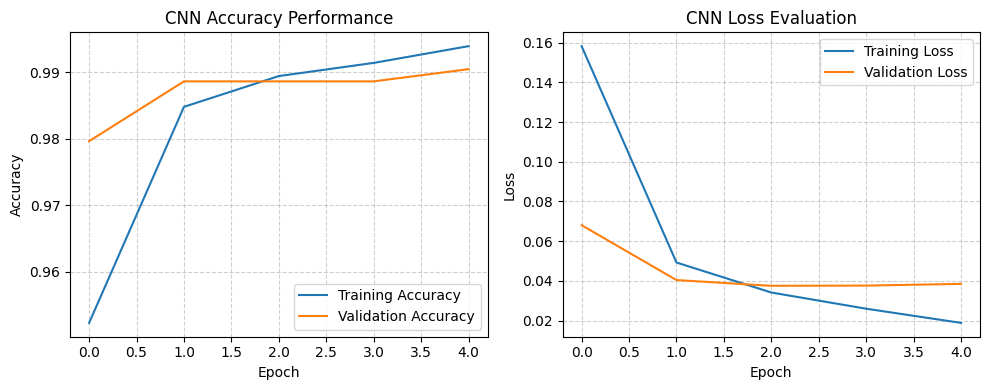

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Normalisasi Data (Asumsi x_train, y_train, x_test sudah di-load ke dalam memori)
x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

# 2. Arsitektur Model Terstruktur
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # add conv2d
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. Kompilasi Model dengan Error Handling yang Tepat
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Eksekusi Pelatihan
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.1
)

# 5. Visualisasi Metrik Performa
plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Ya, penambahan lapisan Conv2D terbukti meningkatkan akurasi validasi (dari stagnasi ~0.988 menjadi ~0.991) karena arsitektur jaringan yang lebih dalam memungkinkan ekstraksi pola fitur visual yang lebih kompleks. Meskipun demikian, penambahan kompleksitas ini memicu indikasi awal *overfitting*, yang dibuktikan oleh tren kenaikan *validation loss* setelah epoch kedua sementara *training loss* terus mengalami penurunan.

## Praktikum D4 - Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 38ms/step - accuracy: 0.1995 - loss: 2.3962 - val_accuracy: 0.3074 - val_loss: 1.7890
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.4239 - loss: 1.5514 - val_accuracy: 0.4964 - val_loss: 1.3709
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.5308 - loss: 1.3031 - val_accuracy: 0.5540 - val_loss: 1.2530
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.5897 - loss: 1.1599 - val_accuracy: 0.5912 - val_loss: 1.1614
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.6291 - loss: 1.0627 - val_accuracy: 0.5976 - val_loss: 1.1807
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.6561 - loss: 0.9875 - val_accuracy: 0.6132 - val_loss: 1.1312
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.6759 - loss: 0.9277 - val_accuracy: 0.6352 - val_loss: 1.0970
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.7000 -

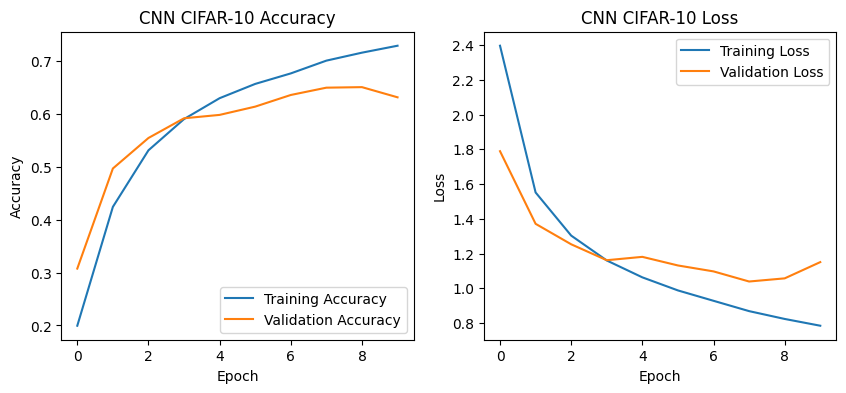

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

# plothistory
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

tugas kecil: tambahkan Dropout(0.5) sebelum lapisan Dense terakhir. Apa pengaruhnya pada overfitting?

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 42ms/step - accuracy: 0.2436 - loss: 1.9741 - val_accuracy: 0.4008 - val_loss: 1.6979
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.3160 - loss: 1.7629 - val_accuracy: 0.5058 - val_loss: 1.4376
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 39ms/step - accuracy: 0.3503 - loss: 1.6893 - val_accuracy: 0.5400 - val_loss: 1.3719
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.3806 - loss: 1.6233 - val_accuracy: 0.5372 - val_loss: 1.3330
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.4029 - loss: 1.5735 - val_accuracy: 0.5824 - val_loss: 1.2605
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.4215 - loss: 1.5312 - val_accuracy: 0.5758 - val_loss: 1.2285
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.4385 - loss: 1.4922 - val_accuracy: 0.5978 - val_loss: 1.1808
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step - accuracy: 0.4454 -

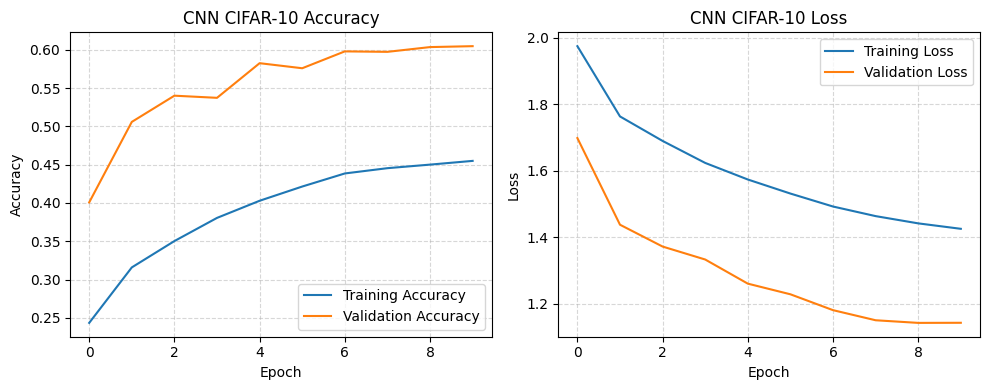

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Input, layers, models
from tensorflow.keras.datasets import cifar10

# load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# normalisasi matrik pixel ke skala [0,1]
x_train_cnn = x_train.astype('float32') / 255.0
x_test_cnn = x_test.astype('float32') / 255.0

model = models.Sequential([
    Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), #injeksi dropout sebelum layer klasifikasi akhir
    layers.Dense(10, activation='softmax')
])

# kompilasi model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# pelatihan model
history = model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.1
)

plt.figure(figsize=(10, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Penambahan lapisan `Dropout(0.5)` terbukti secara signifikan menekan indikasi *overfitting* pada model, di mana pada pengujian tanpa *dropout* terjadi divergensi tajam antara *training accuracy* (72,82%) dan *validation accuracy* (63,08%) yang disertai kenaikan kembali (*rebound*) nilai *validation loss* hingga 1,1505 pada epoch ke-10. Setelah *dropout* diinjeksi, tren kenaikan *validation loss* berhasil distabilkan pada kisaran 1,1429 dan celah generalisasi berhasil ditutup, meskipun terjadi penurunan laju konvergensi *training accuracy* (45,49%) akibat dimatikannya 50% unit neuron secara acak selama fase pelatihan. Secara keseluruhan, teknik regulasi ini efektif mencegah jaringan dari menghafal *noise* pada data latih dan memaksa model untuk mempelajari representasi fitur yang lebih independen.

## Praktikum D5 - Transfer Learning dengan Model Pra-Latih

Bagaimana jika kita gunakan “otak” yang sudah cerdas? Misalnya VGG16 atau ResNet50
yang sudah dilatih di ImageNet. Kita tinggal memanfaatkannya.

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 570s 404ms/step - accuracy: 0.4509 - loss: 2.3307 - val_accuracy: 0.5316 - val_loss: 1.3517
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 530s 376ms/step - accuracy: 0.5742 - loss: 1.2281 - val_accuracy: 0.5722 - val_loss: 1.2452
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 566s 402ms/step - accuracy: 0.6068 - loss: 1.1348 - val_accuracy: 0.5948 - val_loss: 1.2113
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 585s 416ms/step - accuracy: 0.6281 - loss: 1.0781 - val_accuracy: 0.5930 - val_loss: 1.1973
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 566s 403ms/step - accuracy: 0.6410 - loss: 1.0408 - val_accuracy: 0.5892 - val_loss: 1.2320


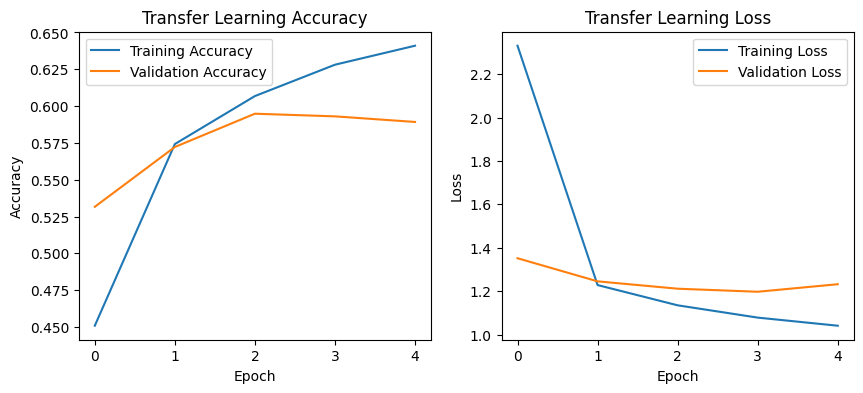

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
  )
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Tugas kecil: Coba aktifkan 1–2 lapisan terakhir dari base_model (fine-tuning). Bagaimana akurasinya berubah?

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 639s 453ms/step - accuracy: 0.4027 - loss: 2.1173 - val_accuracy: 0.5514 - val_loss: 1.3731
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 631s 449ms/step - accuracy: 0.5673 - loss: 1.2975 - val_accuracy: 0.5884 - val_loss: 1.2139
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 627s 446ms/step - accuracy: 0.6011 - loss: 1.1833 - val_accuracy: 0.6066 - val_loss: 1.1394
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 639s 454ms/step - accuracy: 0.6210 - loss: 1.1207 - val_accuracy: 0.6230 - val_loss: 1.0971
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 608s 432ms/step - accuracy: 0.6351 - loss: 1.0777 - val_accuracy: 0.6394 - val_loss: 1.0671
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 608s 432ms/step - accuracy: 0.6451 - loss: 1.0442 - val_accuracy: 0.6324 - val_loss: 1.0485
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 634s 451ms/step - accuracy: 0.6542 - loss: 1.0164 - val_accuracy: 0.6492 - val_loss: 1.0221
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 732s 520ms/step - accuracy: 

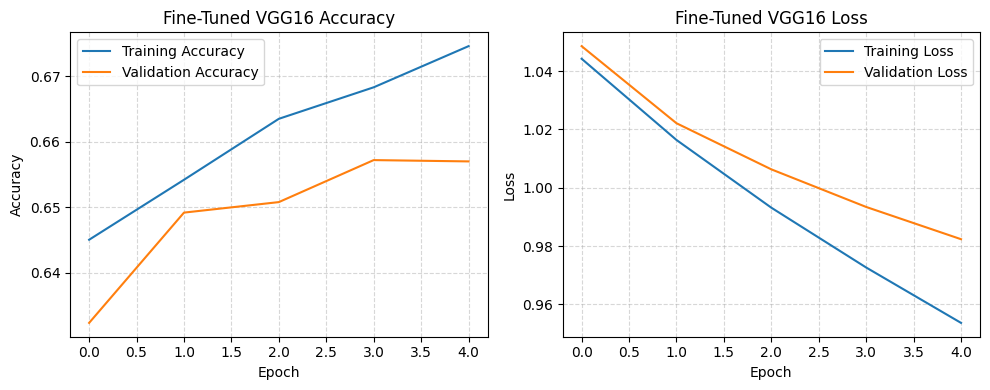

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# load dan normalisasi data cifar-10
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# fine tuning: aktifkan 2 layer terakhir dari base_model
base_model.trainable = True
for layer in base_model.layers[:-2]: # bekukan semua layer kecuali 2 terakhir
  layer.trainable = False

# menyusun arsitektur model klasifikasi
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='softmax')
])

# komilasi layer (wajib menggunakan learning rate kecil saat fine-tuning)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# pelatihan model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

# eksekusi pelatihan model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fine-Tuned VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Fine-Tuned VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

## Praktikum D6 - Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 350ms/step
              precision    recall  f1-score   support

           0       0.69      0.74      0.72      1000
           1       0.73      0.73      0.73      1000
           2       0.58      0.56      0.57      1000
           3       0.48      0.50      0.49      1000
           4       0.61      0.56      0.58      1000
           5       0.63      0.49      0.55      1000
           6       0.63      0.73      0.68      1000
           7       0.73      0.67      0.70      1000
           8       0.79      0.75      0.77      1000
           9       0.65      0.78      0.71      1000

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.65     10000
weighted avg       0.65      0.65      0.65     10000



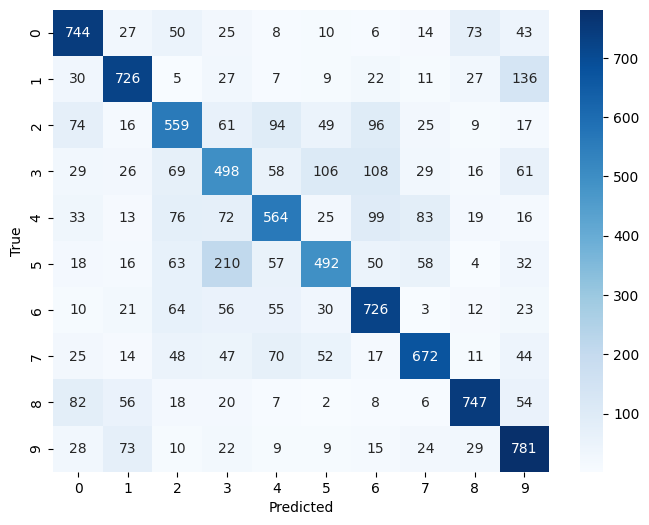

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Penugasan

Mencoba klasifikasi tulisan angka:
1. Tulis 1–3 digit (0–9) di kertas putih dengan spidol/bolpen tebal (ukuran besar, kontras jelas).
2. Foto lurus dari atas, pencahayaan merata, tanpa bayangan besar.
3. Upload foto ke Google Colab.
4. Pre-process gambar agar sesuai format MNIST (28×28, grayscale).
5. Klasifikasi dengan salah satu model:
    - CNN (D3) → butuh tensor shape (1, 28, 28, 1)
    - SVM (D2) → butuh vektor 784 (flatten 28×28)



Upload dan Pre-process

Pilih dan unggah 1 foto angka tulisan tangan Anda:


Saving digit_2.jpg to digit_2 (1).jpg


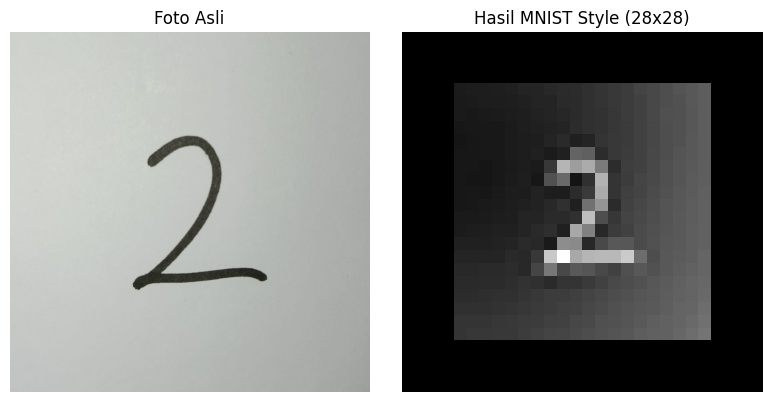


[INFO] Shape tensor hasil preprocessing: (28, 28, 1)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from google.colab import files

def preprocess_to_mnist_28x28(img_pil):
    # Grayscale & Auto-contrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)

    arr = np.array(img).astype(np.uint8)

    # Invert warna jika background terang (kertas putih -> digit putih di atas latar hitam)
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Auto-crop ke area bounding box digit
    thr = np.mean(arr) * 0.8
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1 + 1, y1 + 1))

    # Resize ke 20x20 dengan mempertahankan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Tempelkan ke canvas 28x28 tepat di tengah (centering)
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w) // 2, (28 - h) // 2))

    # Normalisasi piksel ke skala [0, 1] dan tambah dimensi channel (28, 28, 1)
    arr = np.array(canvas).astype('float32') / 255.0
    arr = arr[..., None]

    return canvas, arr

# upload foto
print("Pilih dan unggah 1 foto angka tulisan tangan Anda:")
uploaded = files.upload()

# Ambil nama berkas secara otomatis
filename = list(uploaded.keys())[0]
img_pil = Image.open(filename)

# running pre-process
canvas_28x28, tensor_input = preprocess_to_mnist_28x28(img_pil)

# visualisasi perbanding (asli vs after)
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title("Foto Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canvas_28x28, cmap='gray')
plt.title("Hasil MNIST Style (28x28)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Menampilkan bentuk tensor yang siap digunakan untuk tahap prediksi nanti
print(f"\n[INFO] Shape tensor hasil preprocessing: {tensor_input.shape}")